# НАПИСАТЬ

## Импорты и загрузки

In [1]:
from pathlib import Path
import pandas as pd

# === 1. Базовые пути ===
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parents[2]

OUTPUTS_DIR = PROJECT_ROOT / "outputs" / "ssl_ch7_checkpoint_selection_dev"
SUMMARY_DIR = OUTPUTS_DIR / "tables" 
TABLES_OUTPUT_DIR = OUTPUTS_DIR / "tables"
FIGURES_OUTPUT_DIR = OUTPUTS_DIR / "figures"


# === 2. Путь к объединённой таблице ===
combined_csv_path = SUMMARY_DIR / "summary_all.csv"

print("CSV path:", combined_csv_path)

# === 3. Загрузка ===
df_all = pd.read_csv(combined_csv_path)

# === 4. Быстрая проверка ===
print("\nShape:", df_all.shape)
display(df_all.head())

CSV path: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\ssl_ch7_checkpoint_selection_dev\tables\summary_all.csv

Shape: (60, 39)


,subject_id,group,p,scenario,channel_set,n_channels,channels,ft_strategy,seed,encoder_checkpoint,...,recall,fdr,run_tag,history_path,predictions_path,status,error,ssl_epoch,ssl_checkpoint,selection_stage
0,subj_054,benchmark,40,ssl_ft,ch7,7,"Cz,Pz,Oz,P3,P4,PO7,PO8",full_ft,42,/kaggle/input/datasets/taisiyaglazova/ssl-7-ch...,...,0.994135,0.007928,ch7__benchmark__subj_054__p40__ssl_ft__seed42_...,NaN,NaN,ok,NaN,5,/kaggle/input/datasets/taisiyaglazova/ssl-7-ch...,dev_checkpoint_selection
1,subj_054,benchmark,60,ssl_ft,ch7,7,"Cz,Pz,Oz,P3,P4,PO7,PO8",full_ft,42,/kaggle/input/datasets/taisiyaglazova/ssl-7-ch...,...,0.571848,0.314566,ch7__benchmark__subj_054__p60__ssl_ft__seed42_...,NaN,NaN,ok,NaN,5,/kaggle/input/datasets/taisiyaglazova/ssl-7-ch...,dev_checkpoint_selection
2,subj_054,benchmark,100,ssl_ft,ch7,7,"Cz,Pz,Oz,P3,P4,PO7,PO8",full_ft,42,/kaggle/input/datasets/taisiyaglazova/ssl-7-ch...,...,0.689150,0.430115,ch7__benchmark__subj_054__p100__ssl_ft__seed42...,NaN,NaN,ok,NaN,5,/kaggle/input/datasets/taisiyaglazova/ssl-7-ch...,dev_checkpoint_selection
3,subj_065,benchmark,40,ssl_ft,ch7,7,"Cz,Pz,Oz,P3,P4,PO7,PO8",full_ft,42,/kaggle/input/datasets/taisiyaglazova/ssl-7-ch...,...,0.722222,0.021566,ch7__benchmark__subj_065__p40__ssl_ft__seed42_...,NaN,NaN,ok,NaN,5,/kaggle/input/datasets/taisiyaglazova/ssl-7-ch...,dev_checkpoint_selection
4,subj_065,benchmark,60,ssl_ft,ch7,7,"Cz,Pz,Oz,P3,P4,PO7,PO8",full_ft,42,/kaggle/input/datasets/taisiyaglazova/ssl-7-ch...,...,0.777778,0.305309,ch7__benchmark__subj_065__p60__ssl_ft__seed42_...,NaN,NaN,ok,NaN,5,/kaggle/input/datasets/taisiyaglazova/ssl-7-ch...,dev_checkpoint_selection


In [2]:
# Проверка
df_all.groupby(["ssl_epoch", "p"])["subject_id"].nunique()

ssl_epoch  p  
5          40     4
           60     4
           100    4
10         40     4
           60     4
           100    4
15         40     4
           60     4
           100    4
17         40     4
           60     4
           100    4
20         40     4
           60     4
           100    4
Name: subject_id, dtype: int64

## Сводные статистики

In [3]:
import numpy as np

# === 1. Агрегация по ssl_epoch ===
checkpoint_rank = (
    df_all
    .groupby("ssl_epoch", as_index=False)
    .agg(
        mean_auc=("auc", "mean"),
        std_auc=("auc", "std"),
        mean_f1=("f1", "mean"),
        std_f1=("f1", "std"),
        n_runs=("subject_id", "count"),
    )
    .sort_values("mean_auc", ascending=False)
)

# === 1. Агрегация по р ===
checkpoint_summary = (
    df_all
    .groupby(["ssl_epoch", "p"], as_index=False)
    .agg(
        mean_auc=("auc", "mean"),
        std_auc=("auc", "std"),
        mean_f1=("f1", "mean"),
        std_f1=("f1", "std"),
        n_subjects=("subject_id", "nunique"),
    )
)

In [5]:
checkpoint_rank

,ssl_epoch,mean_auc,std_auc,mean_f1,std_f1,n_runs
2,15,0.658453,0.127432,0.256561,0.104391,12
0,5,0.648727,0.128493,0.252944,0.100937,12
1,10,0.647105,0.126538,0.248161,0.106461,12
3,17,0.646296,0.126240,0.252927,0.100973,12
4,20,0.639351,0.128379,0.245674,0.091810,12


In [6]:
checkpoint_summary

,ssl_epoch,p,mean_auc,std_auc,mean_f1,std_f1,n_subjects
0,5,40,0.536523,0.052710,0.185934,0.038238,4
1,5,60,0.667737,0.120213,0.247200,0.081517,4
2,5,100,0.741921,0.120250,0.325699,0.127125,4
3,10,40,0.531611,0.032569,0.185793,0.037501,4
4,10,60,0.648469,0.097476,0.211693,0.057576,4
5,10,100,0.761235,0.113987,0.346997,0.129816,4
6,15,40,0.553092,0.070969,0.195780,0.053430,4
7,15,60,0.674378,0.100733,0.243972,0.093040,4
8,15,100,0.747890,0.136214,0.329931,0.127010,4
9,17,40,0.524668,0.036290,0.185496,0.037085,4


In [4]:
pivot = df_all.pivot_table(
    index=["subject_id", "p"],
    columns="ssl_epoch",
    values="auc"
)

pivot["delta_15_10"] = pivot[15] - pivot[10]
pivot["delta_15_17"] = pivot[15] - pivot[17]

display(pivot)

print("15 >= 10:", (pivot["delta_15_10"] >= 0).mean())
print("15 >= 17:", (pivot["delta_15_17"] >= 0).mean())
print("mean delta 15-10:", pivot["delta_15_10"].mean())
print("mean delta 15-17:", pivot["delta_15_17"].mean())

ssl_epoch              5        10        15        17        20  delta_15_10  \
subject_id p                                                                    
subj_054   40   0.539476  0.548361  0.547510  0.526746  0.530451    -0.000851   
           60   0.715385  0.670635  0.695638  0.691638  0.647168     0.025003   
           100  0.741171  0.749345  0.751553  0.767570  0.745211     0.002208   
subj_065   40   0.609793  0.563693  0.654204  0.574885  0.549004     0.090511   
           60   0.727526  0.746789  0.757029  0.689358  0.730560     0.010240   
           100  0.811642  0.827110  0.803762  0.820089  0.811046    -0.023347   
subj_090   40   0.493279  0.488755  0.493240  0.503888  0.495619     0.004485   
           60   0.739990  0.662685  0.716652  0.679349  0.717519     0.053967   
           100  0.841861  0.862776  0.877427  0.867298  0.857702     0.014651   
subj_094   40   0.503543  0.525637  0.517415  0.493154  0.507918    -0.008222   
           60   0.488048  0.513768  0.528191  0.539011  0.520694     0.014423   
           100  0.573011  0.605711  0.558819  0.602571  0.559319    -0.046892   

ssl_epoch       delta_15_17  
subject_id p                 
subj_054   40      0.020764  
           60      0.004000  
           100    -0.016017  
subj_065   40      0.079319  
           60      0.067672  
           100    -0.016327  
subj_090   40     -0.010648  
           60      0.037303  
           100     0.010128  
subj_094   40      0.024260  
           60     -0.010820  
           100    -0.043752

15 >= 10: 0.6666666666666666
15 >= 17: 0.5833333333333334
mean delta 15-10: 0.011348054516769799
mean delta 15-17: 0.012156853609362172


## График

In [9]:
import matplotlib.pyplot as plt

def plot_auc_vs_epoch_clean(df, save_path=None):
    fig, ax = plt.subplots(figsize=(8, 5))

    p_values = [40, 60, 100]

    # выделяем выбранный checkpoint
    ax.axvspan(14.5, 15.5, color="gray", alpha=0.18, label="выбранный checkpoint")

    for p in p_values:
        sub = df[df["p"] == p].sort_values("ssl_epoch")

        ax.plot(
            sub["ssl_epoch"],
            sub["mean_auc"],
            marker="o",
            linewidth=2,
            label=f"p = {p}%",
        )

    ax.set_xlabel("Эпоха SSL-предобучения")
    ax.set_ylabel("ROC-AUC")
    ax.set_title("Зависимость ROC-AUC от эпохи SSL-предобучения")
    ax.set_xticks(sorted(df["ssl_epoch"].unique()))
    ax.grid(True, alpha=0.3)

    ax.legend(
        title="Объём калибровки",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True,
    )

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        fig.savefig(save_path.with_suffix(".pdf"), bbox_inches="tight")

    return fig

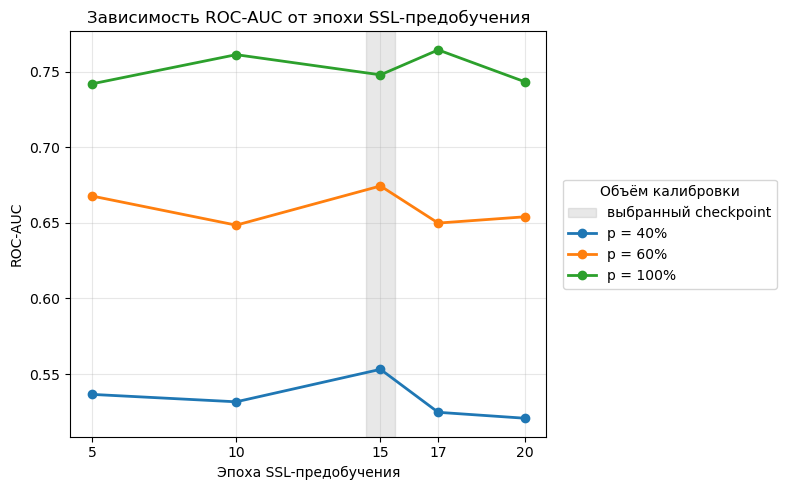

In [12]:
fig = plot_auc_vs_epoch_clean(
    checkpoint_summary,
    save_path=FIGURES_OUTPUT_DIR / "auc_vs_ssl_epoch_checkpoint_selection.png"
)

plt.show()

# ! ДАЛЬШЕ КОД ИЗ СТАРОГО НОУТБУКА НЕПЕРПИСАННЫЙ !

In [9]:
summary_stats[["ssl_epoch", "mean_auc", "mean_f1"]]

,ssl_epoch,mean_auc,mean_f1
0,10,0.646464,0.300624
1,20,0.634402,0.282851
2,30,0.621695,0.274166
3,40,0.619483,0.274811
4,50,0.625670,0.276080
5,60,0.624240,0.274642
6,70,0.618497,0.274454
7,80,0.624086,0.276117
8,90,0.624475,0.278378
9,100,0.627695,0.279944


In [ ]:
# === Сохранение сводной таблицы ===
summary_stats_path = TABLES_OUTPUT_DIR / "summary_stats_by_ssl_epoch.csv"
summary_stats.to_csv(summary_stats_path, index=False)

print("Сводная таблица сохранена:", summary_stats_path)

Сводная таблица сохранена: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\ssl_checkpoints_transfer\tables\summary_stats_by_ssl_epoch.csv


## Построение графиков

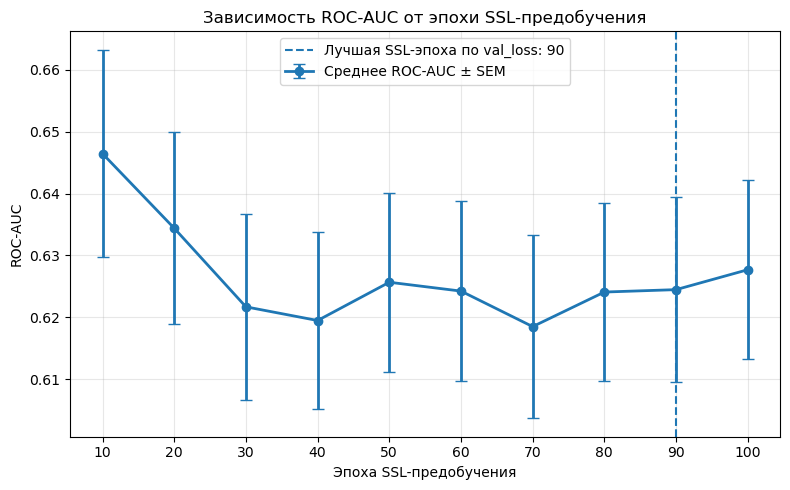

ROC-AUC график сохранён:
c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\ssl_checkpoints_transfer\figures\roc_auc_vs_ssl_epoch.png
c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\ssl_checkpoints_transfer\figures\roc_auc_vs_ssl_epoch.pdf


In [15]:
import matplotlib.pyplot as plt

roc_path_png = FIGURES_OUTPUT_DIR / "roc_auc_vs_ssl_epoch.png"
roc_path_pdf = FIGURES_OUTPUT_DIR / "roc_auc_vs_ssl_epoch.pdf"

# На всякий случай сортируем
summary_stats = summary_stats.sort_values("ssl_epoch")

BEST_SSL_EPOCH = 90

plt.figure(figsize=(8, 5))

plt.errorbar(
    summary_stats["ssl_epoch"],
    summary_stats["mean_auc"],
    yerr=summary_stats["sem_auc"],
    marker="o",
    linewidth=2,
    capsize=4,
    label="Среднее ROC-AUC ± SEM",
)

plt.axvline(
    BEST_SSL_EPOCH,
    linestyle="--",
    linewidth=1.5,
    label=f"Лучшая SSL-эпоха по val_loss: {BEST_SSL_EPOCH}",
)

plt.xlabel("Эпоха SSL-предобучения")
plt.ylabel("ROC-AUC")
plt.title("Зависимость ROC-AUC от эпохи SSL-предобучения")
plt.xticks(summary_stats["ssl_epoch"])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(roc_path_png, dpi=300, bbox_inches="tight")
plt.savefig(roc_path_pdf, bbox_inches="tight")

plt.show()

print("ROC-AUC график сохранён:")
print(roc_path_png)
print(roc_path_pdf)

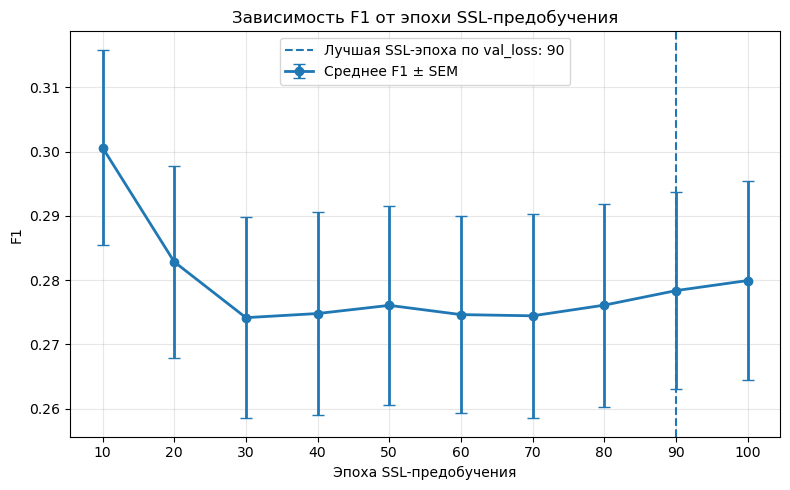

F1 график сохранён:
c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\ssl_checkpoints_transfer\figures\f1_vs_ssl_epoch.png
c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\ssl_checkpoints_transfer\figures\f1_vs_ssl_epoch.pdf


In [16]:
f1_path_png = FIGURES_OUTPUT_DIR / "f1_vs_ssl_epoch.png"
f1_path_pdf = FIGURES_OUTPUT_DIR / "f1_vs_ssl_epoch.pdf"

plt.figure(figsize=(8, 5))

plt.errorbar(
    summary_stats["ssl_epoch"],
    summary_stats["mean_f1"],
    yerr=summary_stats["sem_f1"],
    marker="o",
    linewidth=2,
    capsize=4,
    label="Среднее F1 ± SEM",
)

plt.axvline(
    BEST_SSL_EPOCH,
    linestyle="--",
    linewidth=1.5,
    label=f"Лучшая SSL-эпоха по val_loss: {BEST_SSL_EPOCH}",
)

plt.xlabel("Эпоха SSL-предобучения")
plt.ylabel("F1")
plt.title("Зависимость F1 от эпохи SSL-предобучения")
plt.xticks(summary_stats["ssl_epoch"])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(f1_path_png, dpi=300, bbox_inches="tight")
plt.savefig(f1_path_pdf, bbox_inches="tight")

plt.show()

print("F1 график сохранён:")
print(f1_path_png)
print(f1_path_pdf)

## Загрузка scratch результатов

In [17]:
# === Загрузка scratch summary ===
SCRATCH_TABLES_DIR = PROJECT_ROOT / "outputs" / "downstream" / "test" / "tables"

scratch_path = SCRATCH_TABLES_DIR / "Scratch_summary.csv"  # поправь имя, если отличается

print("Scratch path:", scratch_path)
print("Exists:", scratch_path.exists())

assert scratch_path.exists(), f"Файл не найден: {scratch_path}"

scratch_df = pd.read_csv(scratch_path)

print("Scratch shape:", scratch_df.shape)
display(scratch_df.head())
print(scratch_df.columns.tolist())

Scratch path: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test\tables\Scratch_summary.csv
Exists: True
Scratch shape: (366, 33)


,subject_id,group,p,scenario,ft_strategy,seed,encoder_checkpoint,lr_encoder,lr_head,weight_decay,...,accuracy,f1,precision,recall,fdr,run_tag,history_path,predictions_path,status,error
0,subj_051,benchmark,0,scratch,NaN,42,NaN,0.00003,0.0003,0.001,...,0.882397,0.000000,0.000000,0.000000,0.006737,benchmark__subj_051__p0__scratch__seed42,/kaggle/working/stage5_block2_results/stage5_f...,/kaggle/working/stage5_block2_results/stage5_f...,ok,NaN
1,subj_051,benchmark,10,scratch,NaN,42,NaN,0.00003,0.0003,0.001,...,0.330337,0.217163,0.125888,0.789809,0.021560,benchmark__subj_051__p10__scratch__seed42,/kaggle/working/stage5_block2_results/stage5_f...,/kaggle/working/stage5_block2_results/stage5_f...,ok,NaN
2,subj_051,benchmark,20,scratch,NaN,42,NaN,0.00003,0.0003,0.001,...,0.245693,0.213281,0.121549,0.869427,0.018001,benchmark__subj_051__p20__scratch__seed42,/kaggle/working/stage5_block2_results/stage5_f...,/kaggle/working/stage5_block2_results/stage5_f...,ok,NaN
3,subj_051,benchmark,40,scratch,NaN,42,NaN,0.00003,0.0003,0.001,...,0.351685,0.213539,0.124536,0.748408,0.032400,benchmark__subj_051__p40__scratch__seed42,/kaggle/working/stage5_block2_results/stage5_f...,/kaggle/working/stage5_block2_results/stage5_f...,ok,NaN
4,subj_051,benchmark,60,scratch,NaN,42,NaN,0.00003,0.0003,0.001,...,0.117603,0.210456,0.117603,1.000000,0.008633,benchmark__subj_051__p60__scratch__seed42,/kaggle/working/stage5_block2_results/stage5_f...,/kaggle/working/stage5_block2_results/stage5_f...,ok,NaN


['subject_id', 'group', 'p', 'scenario', 'ft_strategy', 'seed', 'encoder_checkpoint', 'lr_encoder', 'lr_head', 'weight_decay', 'warmup_epochs', 'selected_threshold', 'val_f1_at_selected_threshold', 'n_calib', 'n_val', 'n_test', 'n_pos_calib', 'n_pos_val', 'n_pos_test', 'best_epoch', 'best_val_loss', 'stopped_epoch', 'auc', 'accuracy', 'f1', 'precision', 'recall', 'fdr', 'run_tag', 'history_path', 'predictions_path', 'status', 'error']


In [18]:
# Фильтруем р=100
scratch_p100 = scratch_df[scratch_df["p"] == 100].copy()

print("Scratch p=100 shape:", scratch_p100.shape)
print("p values:", sorted(scratch_p100["p"].unique()))
display(scratch_p100.head())

Scratch p=100 shape: (61, 33)
p values: [np.int64(100)]


,subject_id,group,p,scenario,ft_strategy,seed,encoder_checkpoint,lr_encoder,lr_head,weight_decay,...,accuracy,f1,precision,recall,fdr,run_tag,history_path,predictions_path,status,error
5,subj_051,benchmark,100,scratch,NaN,42,NaN,0.00003,0.0003,0.001,...,0.117603,0.210456,0.117603,1.000000,0.006254,benchmark__subj_051__p100__scratch__seed42,/kaggle/working/stage5_block2_results/stage5_f...,/kaggle/working/stage5_block2_results/stage5_f...,ok,NaN
11,subj_052,benchmark,100,scratch,NaN,42,NaN,0.00003,0.0003,0.001,...,0.170373,0.211925,0.119294,0.948171,0.000131,benchmark__subj_052__p100__scratch__seed42,/kaggle/working/stage5_block2_results/stage5_f...,/kaggle/working/stage5_block2_results/stage5_f...,ok,NaN
17,subj_053,benchmark,100,scratch,NaN,42,NaN,0.00003,0.0003,0.001,...,0.183257,0.211170,0.119122,0.929095,0.009594,benchmark__subj_053__p100__scratch__seed42,/kaggle/working/stage5_block2_results/stage5_f...,/kaggle/working/stage5_block2_results/stage5_f...,ok,NaN
23,subj_055,benchmark,100,scratch,NaN,42,NaN,0.00003,0.0003,0.001,...,0.133106,0.213135,0.119362,0.994220,0.019742,benchmark__subj_055__p100__scratch__seed42,/kaggle/working/stage5_block2_results/stage5_f...,/kaggle/working/stage5_block2_results/stage5_f...,ok,NaN
29,subj_056,benchmark,100,scratch,NaN,42,NaN,0.00003,0.0003,0.001,...,0.150801,0.212002,0.118943,0.974227,0.001407,benchmark__subj_056__p100__scratch__seed42,/kaggle/working/stage5_block2_results/stage5_f...,/kaggle/working/stage5_block2_results/stage5_f...,ok,NaN


## Статистика для Scratch

In [19]:
scratch_stats_p100 = {
    "n_subjects": scratch_p100["subject_id"].nunique(),
    "mean_auc": scratch_p100["auc"].mean(),
    "std_auc": scratch_p100["auc"].std(),
    "sem_auc": scratch_p100["auc"].std() / np.sqrt(scratch_p100["subject_id"].nunique()),
    "mean_f1": scratch_p100["f1"].mean(),
    "std_f1": scratch_p100["f1"].std(),
    "sem_f1": scratch_p100["f1"].std() / np.sqrt(scratch_p100["subject_id"].nunique()),
}

scratch_stats_p100

{'n_subjects': 61,
 'mean_auc': np.float64(0.5560149865612652),
 'std_auc': np.float64(0.0695341686052079),
 'sem_auc': np.float64(0.00890293799693875),
 'mean_f1': np.float64(0.23527527274319543),
 'std_f1': np.float64(0.08552147164343847),
 'sem_f1': np.float64(0.0109499023964955)}

In [22]:
scratch_stats_df = pd.DataFrame([scratch_stats_p100])
scratch_stats_df["p"] = 100
scratch_stats_df.to_csv(
    TABLES_OUTPUT_DIR / "scratch_baseline_p100_stats.csv",
    index=False
)

display(scratch_stats_df)

,n_subjects,mean_auc,std_auc,sem_auc,mean_f1,std_f1,sem_f1,p
0,61,0.556015,0.069534,0.008903,0.235275,0.085521,0.01095,100


## Добавляем scratch baseline на графики

In [23]:
# Значения scratch baseline
scratch_auc = scratch_stats_p100["mean_auc"]
scratch_auc_sem = scratch_stats_p100["sem_auc"]

scratch_f1 = scratch_stats_p100["mean_f1"]
scratch_f1_sem = scratch_stats_p100["sem_f1"]

print("Scratch ROC-AUC:", scratch_auc, "±", scratch_auc_sem)
print("Scratch F1:", scratch_f1, "±", scratch_f1_sem)

Scratch ROC-AUC: 0.5560149865612652 ± 0.00890293799693875
Scratch F1: 0.23527527274319543 ± 0.0109499023964955


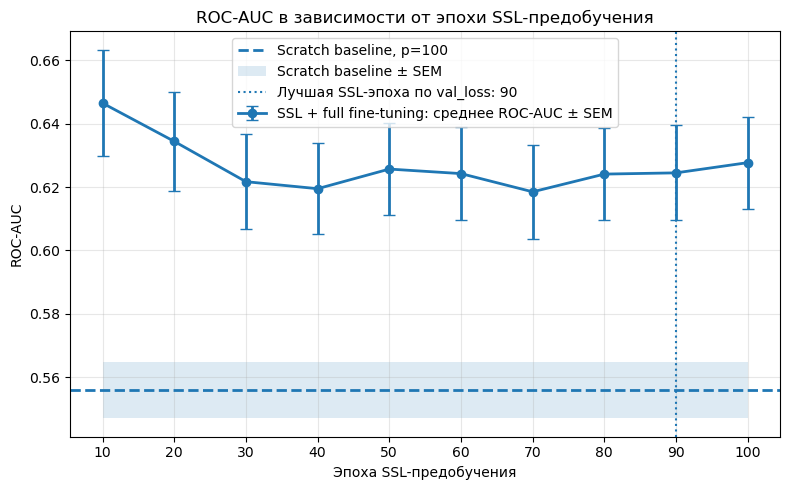

In [25]:
roc_scratch_path_png = TABLES_OUTPUT_DIR / "roc_auc_vs_ssl_epoch_with_scratch.png"
roc_scratch_path_pdf = TABLES_OUTPUT_DIR / "roc_auc_vs_ssl_epoch_with_scratch.pdf"

plt.figure(figsize=(8, 5))

plt.errorbar(
    summary_stats["ssl_epoch"],
    summary_stats["mean_auc"],
    yerr=summary_stats["sem_auc"],
    marker="o",
    linewidth=2,
    capsize=4,
    label="SSL + full fine-tuning: среднее ROC-AUC ± SEM",
)

plt.axhline(
    scratch_auc,
    linestyle="--",
    linewidth=2,
    label="Scratch baseline, p=100",
)

plt.fill_between(
    summary_stats["ssl_epoch"],
    scratch_auc - scratch_auc_sem,
    scratch_auc + scratch_auc_sem,
    alpha=0.15,
    label="Scratch baseline ± SEM",
)

plt.axvline(
    BEST_SSL_EPOCH,
    linestyle=":",
    linewidth=1.5,
    label=f"Лучшая SSL-эпоха по val_loss: {BEST_SSL_EPOCH}",
)

plt.xlabel("Эпоха SSL-предобучения")
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC в зависимости от эпохи SSL-предобучения")
plt.xticks(summary_stats["ssl_epoch"])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(roc_scratch_path_png, dpi=300, bbox_inches="tight")
plt.savefig(roc_scratch_path_pdf, bbox_inches="tight")

plt.show()

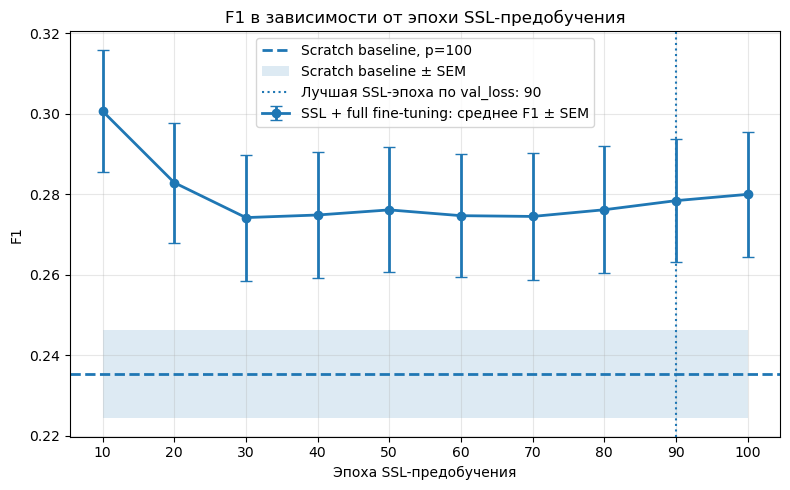

In [27]:
f1_scratch_path_png = TABLES_OUTPUT_DIR / "f1_vs_ssl_epoch_with_scratch.png"
f1_scratch_path_pdf = TABLES_OUTPUT_DIR / "f1_vs_ssl_epoch_with_scratch.pdf"

plt.figure(figsize=(8, 5))

plt.errorbar(
    summary_stats["ssl_epoch"],
    summary_stats["mean_f1"],
    yerr=summary_stats["sem_f1"],
    marker="o",
    linewidth=2,
    capsize=4,
    label="SSL + full fine-tuning: среднее F1 ± SEM",
)

plt.axhline(
    scratch_f1,
    linestyle="--",
    linewidth=2,
    label="Scratch baseline, p=100",
)

plt.fill_between(
    summary_stats["ssl_epoch"],
    scratch_f1 - scratch_f1_sem,
    scratch_f1 + scratch_f1_sem,
    alpha=0.15,
    label="Scratch baseline ± SEM",
)

plt.axvline(
    BEST_SSL_EPOCH,
    linestyle=":",
    linewidth=1.5,
    label=f"Лучшая SSL-эпоха по val_loss: {BEST_SSL_EPOCH}",
)

plt.xlabel("Эпоха SSL-предобучения")
plt.ylabel("F1")
plt.title("F1 в зависимости от эпохи SSL-предобучения")
plt.xticks(summary_stats["ssl_epoch"])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(f1_scratch_path_png, dpi=300, bbox_inches="tight")
plt.savefig(f1_scratch_path_pdf, bbox_inches="tight")

plt.show()

## Статистические тесты

- Wilcoxon signed-rank test
- парные сравнения по субъектам

In [28]:
from scipy.stats import wilcoxon
import pandas as pd
import numpy as np

In [29]:
# SSL: делаем таблицу subject × epoch
ssl_auc_pivot = df_all.pivot(index="subject_id", columns="ssl_epoch", values="auc")
ssl_f1_pivot = df_all.pivot(index="subject_id", columns="ssl_epoch", values="f1")

# Scratch: subject × value
scratch_auc = scratch_p100.set_index("subject_id")["auc"]
scratch_f1 = scratch_p100.set_index("subject_id")["f1"]

print("SSL pivot shape:", ssl_auc_pivot.shape)
print("Scratch shape:", scratch_auc.shape)

SSL pivot shape: (61, 10)
Scratch shape: (61,)


### SSL vs Scratch

In [30]:
results_ssl_vs_scratch = []

for epoch in ssl_auc_pivot.columns:
    auc_ssl = ssl_auc_pivot[epoch]
    f1_ssl = ssl_f1_pivot[epoch]

    # выравниваем индексы
    common_idx = auc_ssl.index.intersection(scratch_auc.index)

    stat_auc, p_auc = wilcoxon(auc_ssl.loc[common_idx], scratch_auc.loc[common_idx])
    stat_f1, p_f1 = wilcoxon(f1_ssl.loc[common_idx], scratch_f1.loc[common_idx])

    results_ssl_vs_scratch.append({
        "ssl_epoch": epoch,
        "p_value_auc": p_auc,
        "p_value_f1": p_f1,
    })

ssl_vs_scratch_df = pd.DataFrame(results_ssl_vs_scratch)
display(ssl_vs_scratch_df)

,ssl_epoch,p_value_auc,p_value_f1
0,10,1.271329e-07,4.633245e-09
1,20,4.508395e-08,4.257334e-08
2,30,4.329237e-08,6.234584e-07
3,40,1.129947e-07,3.228629e-08
4,50,1.003836e-07,1.010758e-08
5,60,8.913975e-08,1.504297e-08
6,70,3.882487e-07,1.943591e-07
7,80,1.482136e-08,1.737139e-07
8,90,2.028157e-07,1.222400e-07
9,100,4.694732e-08,7.863416e-09


In [31]:
# Поправка на множественное сравнение
from statsmodels.stats.multitest import multipletests

ssl_vs_scratch_df["p_adj_auc"] = multipletests(
    ssl_vs_scratch_df["p_value_auc"], method="holm"
)[1]

ssl_vs_scratch_df["p_adj_f1"] = multipletests(
    ssl_vs_scratch_df["p_value_f1"], method="holm"
)[1]

display(ssl_vs_scratch_df)

,ssl_epoch,p_value_auc,p_value_f1,p_adj_auc,p_adj_f1
0,10,1.271329e-07,4.633245e-09,5.348385e-07,4.633245e-08
1,20,4.508395e-08,4.257334e-08,3.896313e-07,2.128667e-07
2,30,4.329237e-08,6.234584e-07,3.896313e-07,6.234584e-07
3,40,1.129947e-07,3.228629e-08,5.348385e-07,1.937177e-07
4,50,1.003836e-07,1.010758e-08,5.348385e-07,8.086061e-08
5,60,8.913975e-08,1.504297e-08,5.348385e-07,1.053008e-07
6,70,3.882487e-07,1.943591e-07,5.348385e-07,5.211418e-07
7,80,1.482136e-08,1.737139e-07,1.482136e-07,5.211418e-07
8,90,2.028157e-07,1.222400e-07,5.348385e-07,4.889598e-07
9,100,4.694732e-08,7.863416e-09,3.896313e-07,7.077074e-08


### Epoch 10 vs Epoch 90

In [32]:
epoch_a = 10
epoch_b = 90

auc_a = ssl_auc_pivot[epoch_a]
auc_b = ssl_auc_pivot[epoch_b]

f1_a = ssl_f1_pivot[epoch_a]
f1_b = ssl_f1_pivot[epoch_b]

stat_auc, p_auc = wilcoxon(auc_a, auc_b)
stat_f1, p_f1 = wilcoxon(f1_a, f1_b)

print(f"AUC: epoch {epoch_a} vs {epoch_b}: p = {p_auc}")
print(f"F1 : epoch {epoch_a} vs {epoch_b}: p = {p_f1}")

AUC: epoch 10 vs 90: p = 0.0069939484957850795
F1 : epoch 10 vs 90: p = 0.0004841064709567201


### Epoch 10 vs Epoch 100

In [33]:
epoch_c = 100

auc_c = ssl_auc_pivot[epoch_c]
f1_c = ssl_f1_pivot[epoch_c]

stat_auc, p_auc = wilcoxon(auc_a, auc_c)
stat_f1, p_f1 = wilcoxon(f1_a, f1_c)

print(f"AUC: epoch {epoch_a} vs {epoch_c}: p = {p_auc}")
print(f"F1 : epoch {epoch_a} vs {epoch_c}: p = {p_f1}")

AUC: epoch 10 vs 100: p = 0.004500224925650785
F1 : epoch 10 vs 100: p = 0.0008764642805709032
